In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [2]:
!unzip WikiSQL_new_compressed.zip

Archive:  WikiSQL_new_compressed.zip
  inflating: test.csv                
  inflating: __MACOSX/._test.csv     
  inflating: train.csv               
  inflating: __MACOSX/._train.csv    
  inflating: validation.csv          
  inflating: __MACOSX/._validation.csv  


In [3]:
train_path = "train.csv"  #May need to update these paths this later
val_path = "validation.csv"
test_path = "test.csv"

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print("Training Set:")
df_train.info()
print("\nValidation Set:")
df_val.info()
print("\nTest Set:")
df_test.info()

df_train.head(), df_val.head(), df_test.head()

Training Set:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56355 entries, 0 to 56354
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   phase     56355 non-null  int64 
 1   question  56355 non-null  object
 2   table     56355 non-null  object
 3   sql       56355 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB

Validation Set:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8421 entries, 0 to 8420
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   phase     8421 non-null   int64 
 1   question  8421 non-null   object
 2   table     8421 non-null   object
 3   sql       8421 non-null   object
dtypes: int64(1), object(3)
memory usage: 263.3+ KB

Test Set:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15878 entries, 0 to 15877
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0

(   phase                                           question  \
 0      1    Tell me what the notes are for South Australia    
 1      1  What is the current series where the new serie...   
 2      1            What is the format for South Australia?   
 3      1  Name the background colour for the Australian ...   
 4      1      how many times is the fuel propulsion is cng?   
 
                                                table  \
 0  {'header': array(['State/territory', 'Text/bac...   
 1  {'header': array(['State/territory', 'Text/bac...   
 2  {'header': array(['State/territory', 'Text/bac...   
 3  {'header': array(['State/territory', 'Text/bac...   
 4  {'header': array(['Order Year', 'Manufacturer'...   
 
                                                  sql  
 0  {'human_readable': 'SELECT Notes FROM table WH...  
 1  {'human_readable': 'SELECT Current series FROM...  
 2  {'human_readable': 'SELECT Format FROM table W...  
 3  {'human_readable': 'SELECT Text/background

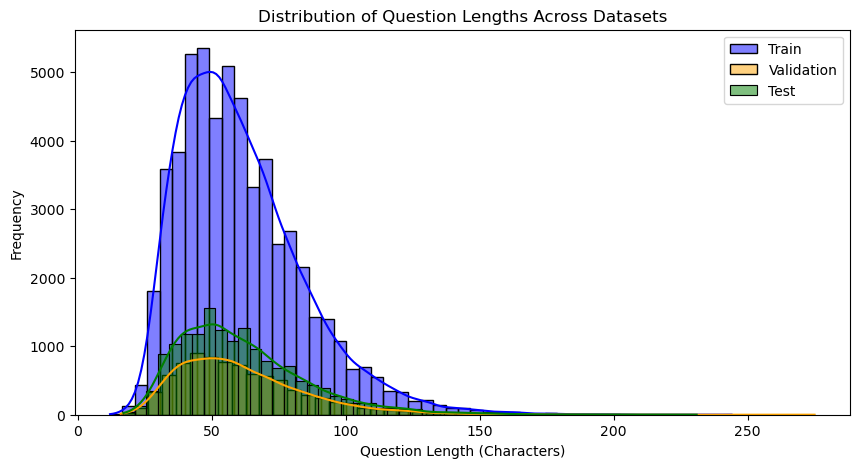

In [2]:

df_train['question_length'] = df_train['question'].apply(len)
df_train['sql_length'] = df_train['sql'].apply(len)

df_val['question_length'] = df_val['question'].apply(len)
df_val['sql_length'] = df_val['sql'].apply(len)

df_test['question_length'] = df_test['question'].apply(len)
df_test['sql_length'] = df_test['sql'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df_train['question_length'], bins=50, kde=True, color='blue', label='Train')
sns.histplot(df_val['question_length'], bins=50, kde=True, color='orange', label='Validation')
sns.histplot(df_test['question_length'], bins=50, kde=True, color='green', label='Test')
plt.xlabel("Question Length (Characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Question Lengths Across Datasets")
plt.legend()
plt.show()


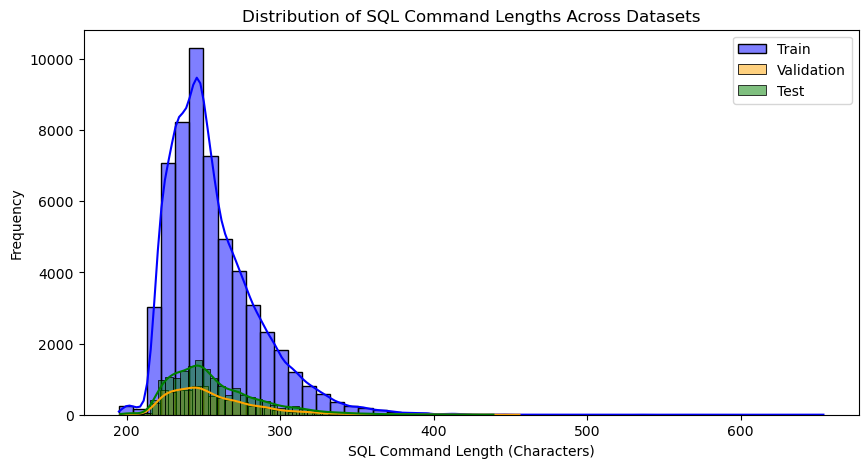

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['sql_length'], bins=50, kde=True, color='blue', label='Train')
sns.histplot(df_val['sql_length'], bins=50, kde=True, color='orange', label='Validation')
sns.histplot(df_test['sql_length'], bins=50, kde=True, color='green', label='Test')
plt.xlabel("SQL Command Length (Characters)")
plt.ylabel("Frequency")
plt.title("Distribution of SQL Command Lengths Across Datasets")
plt.legend()
plt.show()


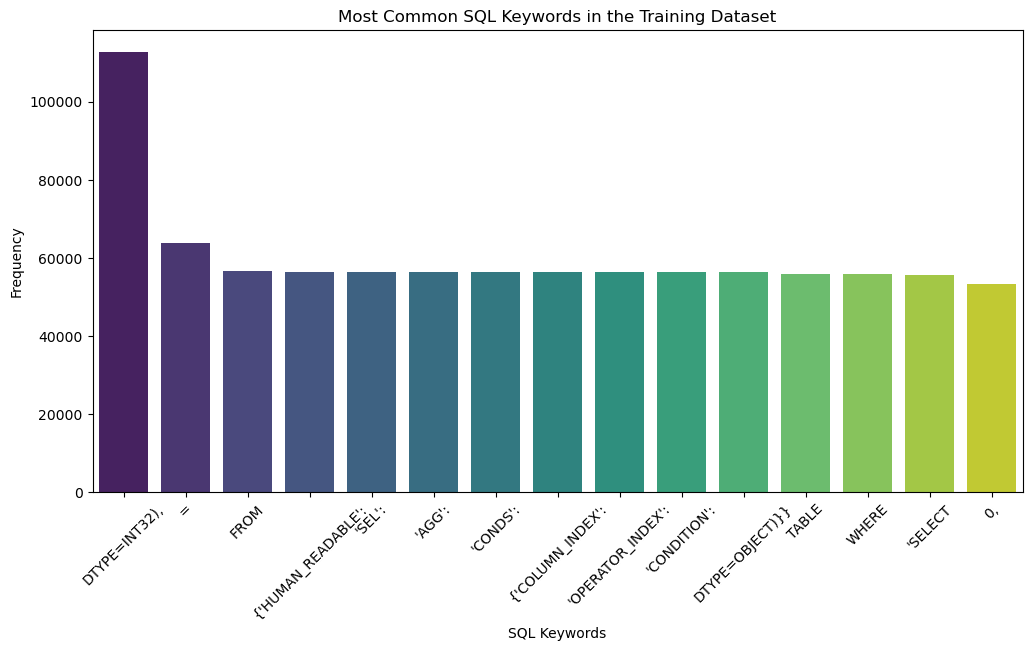

In [4]:
from collections import Counter

sql_text = ' '.join(df_train['sql']).upper()
sql_words = sql_text.split()
common_sql_words = Counter(sql_words)

top_sql_words = common_sql_words.most_common(15)

sql_keywords_df = pd.DataFrame(top_sql_words, columns=['Keyword', 'Count'])

plt.figure(figsize=(12,6))
sns.barplot(x=sql_keywords_df['Keyword'], y=sql_keywords_df['Count'], palette='viridis')
plt.xlabel("SQL Keywords")
plt.ylabel("Frequency")
plt.title("Most Common SQL Keywords in the Training Dataset")
plt.xticks(rotation=45)
plt.show()


In [5]:
spider_path = "spider_dataset.csv"
df_spider = pd.read_csv(spider_path)

print("Spider Dataset:")
df_spider.info()
df_spider.head()


Spider Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text_query   8034 non-null   object
 1   sql_command  8034 non-null   object
dtypes: object(2)
memory usage: 125.7+ KB


,text_query,sql_command
0,How many heads of the departments are older th...,SELECT count(*) FROM head WHERE age > 56
1,"List the name, born state and age of the heads...","SELECT name , born_state , age FROM head ORD..."
2,"List the creation year, name and budget of eac...","SELECT creation , name , budget_in_billions ..."
3,What are the maximum and minimum budget of the...,"SELECT max(budget_in_billions) , min(budget_i..."
4,What is the average number of employees of the...,SELECT avg(num_employees) FROM department WHER...


In [6]:
df_spider.tail()

,text_query,sql_command
8029,What are the citizenships that are shared by s...,SELECT Citizenship FROM singer WHERE Birth_Yea...
8030,How many available features are there in total?,SELECT count(*) FROM Other_Available_Features
8031,What is the feature type name of feature AirCon?,SELECT T2.feature_type_name FROM Other_Availab...
8032,Show the property type descriptions of propert...,SELECT T2.property_type_description FROM Prope...
8033,What are the names of properties that are eith...,SELECT property_name FROM Properties WHERE pro...


In [7]:
duplicate_count = df_spider.duplicated().sum()

df_cleaned = df_spider.drop_duplicates()

df_cleaned['query_length'] = df_cleaned['text_query'].apply(len)
df_cleaned['sql_length'] = df_cleaned['sql_command'].apply(len)

print("Number of duplicate rows removed:", duplicate_count)
df_cleaned.describe()


Number of duplicate rows removed: 21


/var/folders/65/6h6gzl8j01qfc5p_vtxlkf100000gn/T/ipykernel_22631/1108003921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['query_length'] = df_cleaned['text_query'].apply(len)
/var/folders/65/6h6gzl8j01qfc5p_vtxlkf100000gn/T/ipykernel_22631/1108003921.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['sql_length'] = df_cleaned['sql_command'].apply(len)


,query_length,sql_length
count,8013.000000,8013.000000
mean,70.579933,109.410084
std,23.720482,64.309696
min,16.000000,18.000000
25%,54.000000,62.000000
50%,68.000000,92.000000
75%,85.000000,146.000000
max,224.000000,577.000000


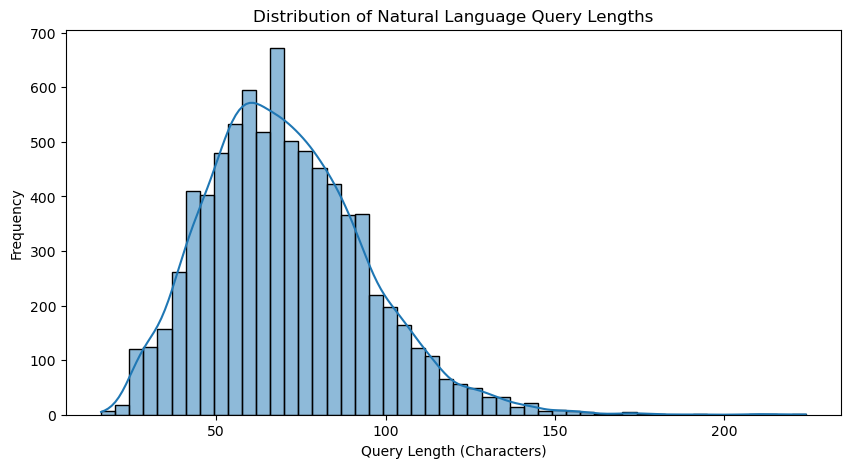

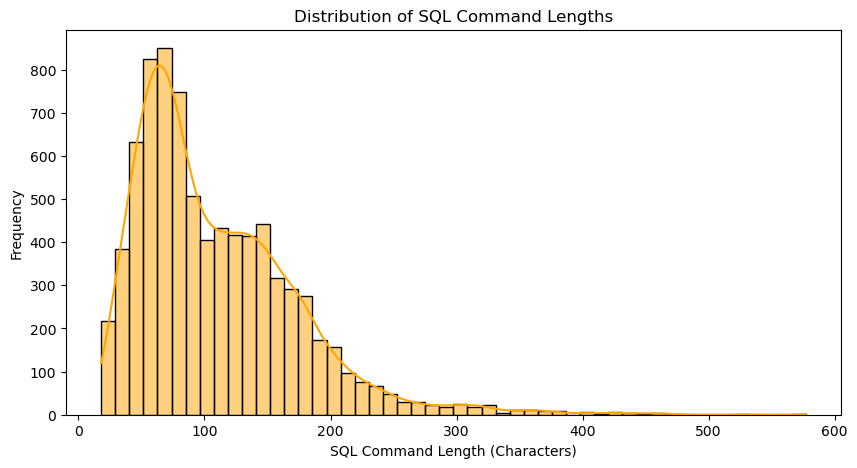

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df_cleaned['query_length'], bins=50, kde=True)
plt.xlabel('Query Length (Characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Natural Language Query Lengths')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df_cleaned['sql_length'], bins=50, kde=True, color='orange')
plt.xlabel('SQL Command Length (Characters)')
plt.ylabel('Frequency')
plt.title('Distribution of SQL Command Lengths')
plt.show()

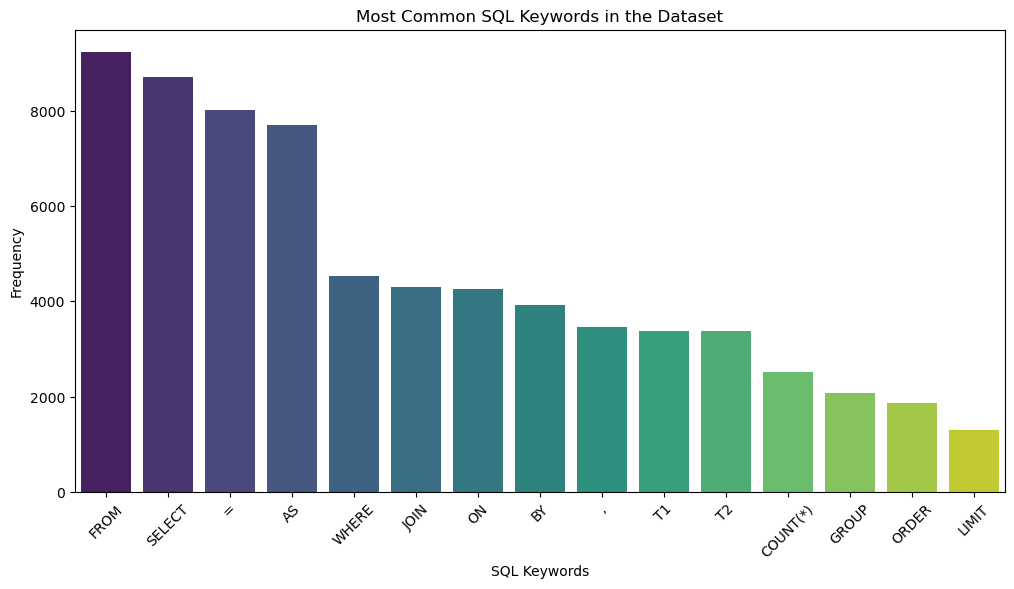

In [9]:
sql_text = ' '.join(df_cleaned['sql_command']).upper()
sql_words = sql_text.split()
common_sql_words = Counter(sql_words)

top_sql_words = common_sql_words.most_common(15)

sql_keywords_df = pd.DataFrame(top_sql_words, columns=['Keyword', 'Count'])

plt.figure(figsize=(12,6))
sns.barplot(x=sql_keywords_df['Keyword'], y=sql_keywords_df['Count'], palette='viridis')
plt.xlabel('SQL Keywords')
plt.ylabel('Frequency')
plt.title('Most Common SQL Keywords in the Dataset')
plt.xticks(rotation=45)
plt.show()